# eJagruti · Multiple Linear Regression + Gradient Descent
### A fully solved notebook in 44 steps

This notebook reproduces the **same synthetic marketing example** as the seven infographics. It includes the raw data, manual calculations, full-batch gradient descent implemented in NumPy, charts, original-scale coefficients, held-out evaluation, and numerical verification.

**Source:** a constructed teaching dataset. This is **not** the house-price CSV and **not** the manufacturing example in the visual-style reference.

| Convention | Choice |
|---|---|
| Inputs | Ad spend, visitors, discount |
| Target | Daily revenue |
| Money units | ₹ thousands/day |
| Visitors | People/day, not thousands |
| Discount | Percentage points: enter 8 for 8% |
| Training / held-out | M01–M08 / M09–M10 |
| Scaling | Inputs only, using training means and population SDs |
| Error during training | Predicted − actual |
| Cost | Half-MSE: $J=\frac1{2m}\sum_i(\hat y_i-y_i)^2$ |
| Learning rate | 0.1 |
| Initialization | Weights and bias = 0 |
| Updates | Simultaneous, full batch, 200 updates |
| Residual in evaluation | Actual − predicted |

**Run:** open in Jupyter, VS Code, or Google Colab and select **Run All**. All data are embedded; no external CSV is required. Saved outputs let you read the solved example without running it. The final cell exports 12 CSV files into a folder named **mlr_notebook_outputs** in the current working directory.

**Seven parts:** 1–7 data · 8–14 standardization · 15–19 predictions/cost · 20–29 first update · 30–34 convergence · 35–39 original units · 40–44 evaluation.


### Setup

Dependencies: NumPy, pandas, matplotlib, and an IPython/Jupyter kernel. If needed, uncomment the next cell to install the packages, then restart the kernel.


In [1]:
# %pip install numpy pandas matplotlib ipykernel


In [2]:
from io import StringIO
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")
plt.rcParams.update({
    "figure.figsize": (10, 4.5), "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.2,
})
COLORS = ["#1767c5", "#007c78", "#aa5900"]
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | "
      f"pandas {pd.__version__} | matplotlib {matplotlib.__version__}")


Python 3.13.12 | NumPy 2.5.3 | pandas 3.0.5 | matplotlib 3.11.2


## 1. Understand the Business Problem

Predict daily revenue from advertising spend, website visitors, and discount rate. Follow every number from raw data to a fitted equation.

Business interpretations hold the other inputs fixed. These are fitted associations, not causal effects. Synthetic observations and two held-out rows cannot establish real business performance.


## 2. Understand the Variables

The ID is a label and must not be used as a numeric predictor.


In [3]:
FEATURES = ["Ad_spend", "Visitors", "Discount"]
TARGET = "Revenue"
variables = pd.DataFrame([
    ("X1", "Ad_spend", "Advertising spend", "INR thousands/day", "Predictor"),
    ("X2", "Visitors", "Website visitors", "People/day", "Predictor"),
    ("X3", "Discount", "Discount offered", "Percentage points", "Predictor"),
    ("Y", "Revenue", "Daily revenue", "INR thousands/day", "Target"),
    ("—", "ID", "Observation identifier", "Label", "Not a predictor"),
], columns=["Symbol", "Column", "Meaning", "Unit", "Role"])
display(variables)


,Symbol,Column,Meaning,Unit,Role
0,X1,Ad_spend,Advertising spend,INR thousands/day,Predictor
1,X2,Visitors,Website visitors,People/day,Predictor
2,X3,Discount,Discount offered,Percentage points,Predictor
3,Y,Revenue,Daily revenue,INR thousands/day,Target
4,—,ID,Observation identifier,Label,Not a predictor


## 3. Write the Multiple Linear Regression Equation

In original units:
$$
\hat y=\beta_0+\beta_1X_1+\beta_2X_2+\beta_3X_3.
$$
After standardizing the inputs:
$$
\hat y=b+w_1z_1+w_2z_2+w_3z_3,\qquad z_j=(X_j-\mu_j)/\sigma_j.
$$
We use $w,b$ for standardized-input parameters and $\beta,\beta_0$ for original-input parameters. **Revenue remains in original units.**


## 4. Inspect the Raw Data

The 14 raw rows include four deliberately introduced data-quality problems. The second M03 is an exact duplicate.


In [4]:
RAW_CSV = """ID,Ad_spend,Visitors,Discount,Revenue
M01,10,100,5,67
M02,10,100,15,57
M03,10,200,5,93
M04,10,200,15,83
M05,20,100,5,83
M06,20,100,15,73
M07,20,200,5,117
M08,20,200,15,107
M09,12,140,8,79
M10,18,180,12,97
M03,10,200,5,93
M11,,150,10,80
M12,-5,130,10,60
M13,15,160,120,75
"""
raw = pd.read_csv(StringIO(RAW_CSV))
display(raw)
print("Shape:", raw.shape)
display(raw.dtypes.rename("dtype").to_frame())
display(raw.describe())


,ID,Ad_spend,Visitors,Discount,Revenue
0,M01,10.000000,100,5,67
1,M02,10.000000,100,15,57
2,M03,10.000000,200,5,93
3,M04,10.000000,200,15,83
4,M05,20.000000,100,5,83
5,M06,20.000000,100,15,73
6,M07,20.000000,200,5,117
7,M08,20.000000,200,15,107
8,M09,12.000000,140,8,79
9,M10,18.000000,180,12,97


Shape: (14, 5)


,dtype
ID,str
Ad_spend,float64
Visitors,int64
Discount,int64
Revenue,int64


,Ad_spend,Visitors,Discount,Revenue
count,13.000000,14.000000,14.000000,14.000000
mean,13.076923,154.285714,17.500000,83.142857
std,7.041088,42.736093,29.801265,17.046800
min,-5.000000,100.000000,5.000000,57.000000
25%,10.000000,107.500000,5.000000,73.500000
50%,12.000000,155.000000,10.000000,81.500000
75%,20.000000,200.000000,15.000000,93.000000
max,20.000000,200.000000,120.000000,117.000000


## 5. Identify Data-Quality Problems

Required values must be present, ad spend and visitors must be nonnegative, and discount must lie between 0 and 100 percentage points. Negative revenue is also treated as invalid in this example.

Actual issues: **one exact duplicate, one missing ad spend, one negative ad spend, and one discount above 100%**. Conflicting rows with the same ID would require investigation rather than automatic deduplication.


In [5]:
quality_flags = pd.DataFrame({
    "Exact duplicate (after first)": raw.duplicated(keep="first"),
    "Missing required value": raw[["ID", *FEATURES, TARGET]].isna().any(axis=1),
    "Negative ad spend": raw["Ad_spend"].lt(0),
    "Negative visitors": raw["Visitors"].lt(0),
    "Discount outside 0–100": raw["Discount"].lt(0) | raw["Discount"].gt(100),
    "Negative revenue": raw[TARGET].lt(0),
}, index=raw.index)
display(quality_flags.sum().rename("Flagged rows").to_frame())
display(raw.loc[quality_flags.any(axis=1)].join(quality_flags))
print("Rules can overlap; count removed rows with a combined mask.")


,Flagged rows
Exact duplicate (after first),1
Missing required value,1
Negative ad spend,1
Negative visitors,0
Discount outside 0–100,1
Negative revenue,0


,ID,Ad_spend,Visitors,Discount,Revenue,Exact duplicate (after first),Missing required value,Negative ad spend,Negative visitors,Discount outside 0–100,Negative revenue
10,M03,10.000000,200,5,93,True,False,False,False,False,False
11,M11,NaN,150,10,80,False,True,False,False,False,False
12,M12,-5.000000,130,10,60,False,False,True,False,False,False
13,M13,15.000000,160,120,75,False,False,False,False,True,False


Rules can overlap; count removed rows with a combined mask.


## 6. Clean the Dataset

Keep the first M03 and exclude its duplicate. Exclude M11–M13 because their missing/invalid inputs cannot be verified here. Record the reasons. In real projects, investigate corrections and the effect of deletion before using these decisions.


In [6]:
remove_mask = quality_flags.any(axis=1)
cleaning_log = raw.loc[remove_mask].copy()
cleaning_log.insert(0, "CSV_line", cleaning_log.index + 2)
cleaning_log["Reason"] = quality_flags.loc[remove_mask].apply(
    lambda flags: "; ".join(flags.index[flags].tolist()), axis=1
)
cleaned = raw.loc[~remove_mask].reset_index(drop=True)
assert len(raw) == 14 and len(cleaning_log) == 4 and len(cleaned) == 10
assert cleaned[FEATURES + [TARGET]].notna().all().all()
assert cleaned["ID"].is_unique
display(cleaning_log)
print(f"{len(raw)} raw − {len(cleaning_log)} excluded = {len(cleaned)} valid rows")


,CSV_line,ID,Ad_spend,Visitors,Discount,Revenue,Reason
10,12,M03,10.000000,200,5,93,Exact duplicate (after first)
11,13,M11,NaN,150,10,80,Missing required value
12,14,M12,-5.000000,130,10,60,Negative ad spend
13,15,M13,15.000000,160,120,75,Discount outside 0–100


14 raw − 4 excluded = 10 valid rows


## 7. Prepare the Final Cleaned Dataset

Use M01–M08 for training and M09–M10 for held-out evaluation. Fit all scaling statistics on training data only. This fixed teaching split is small and deliberately chosen for transparent calculations.


In [7]:
train_ids = [f"M{i:02d}" for i in range(1, 9)]
test_ids = ["M09", "M10"]
train = cleaned.set_index("ID").loc[train_ids].copy()
test = cleaned.set_index("ID").loc[test_ids].copy()
X_train = train[FEATURES].to_numpy(dtype=float)
y_train = train[TARGET].to_numpy(dtype=float)
X_test = test[FEATURES].to_numpy(dtype=float)
y_test = test[TARGET].to_numpy(dtype=float)
m = len(train)
assert set(train.index).isdisjoint(test.index)
display(cleaned)
print("Training:")
display(train)
print("Held out:")
display(test)


,ID,Ad_spend,Visitors,Discount,Revenue
0,M01,10.000000,100,5,67
1,M02,10.000000,100,15,57
2,M03,10.000000,200,5,93
3,M04,10.000000,200,15,83
4,M05,20.000000,100,5,83
5,M06,20.000000,100,15,73
6,M07,20.000000,200,5,117
7,M08,20.000000,200,15,107
8,M09,12.000000,140,8,79
9,M10,18.000000,180,12,97


Training:


,Ad_spend,Visitors,Discount,Revenue
ID,,,,
M01,10.000000,100,5,67
M02,10.000000,100,15,57
M03,10.000000,200,5,93
M04,10.000000,200,15,83
M05,20.000000,100,5,83
M06,20.000000,100,15,73
M07,20.000000,200,5,117
M08,20.000000,200,15,107


Held out:


,Ad_spend,Visitors,Discount,Revenue
ID,,,,
M09,12.000000,140,8,79
M10,18.000000,180,12,97


## 8. Understand Standardization

$$
z_j=(X_j-\mu_j)/\sigma_j.
$$
Centering and scaling make a shared learning rate more practical when inputs use different units. Standardization does **not** make data normally distributed. Compute means and SDs on the eight training rows; reuse them for the held-out rows. **Do not standardize Y.**


## 9. Calculate Mean of Ad Spend

$$
\mu_1=(4\times10+4\times20)/8=15.
$$


In [8]:
mu_ad = train["Ad_spend"].mean()
print(f"Ad-spend sum = {train['Ad_spend'].sum():.0f}; mean = {mu_ad:.2f} INR thousands/day")


Ad-spend sum = 120; mean = 15.00 INR thousands/day


## 10. Calculate Mean of Visitors

$$
\mu_2=(4\times100+4\times200)/8=150.
$$
In row order: 100, 100, 200, 200, 100, 100, 200, 200.


In [9]:
mu_visitors = train["Visitors"].mean()
print(f"Visitor sum = {train['Visitors'].sum():.0f}; mean = {mu_visitors:.2f} people/day")


Visitor sum = 1200; mean = 150.00 people/day


## 11. Calculate Mean of Discount

$$
\mu_3=(4\times5+4\times15)/8=10.
$$
The discount values alternate 5 and 15 percentage points.


In [10]:
mu_discount = train["Discount"].mean()
print(f"Discount sum = {train['Discount'].sum():.0f}; mean = {mu_discount:.2f} percentage points")


Discount sum = 80; mean = 10.00 percentage points


## 12. Calculate Mean of Revenue

$$
\bar y=(67+57+93+83+83+73+117+107)/8=680/8=85.
$$
This helps interpret the bias of centered predictors, but is not used to scale revenue.


In [11]:
mean_y = y_train.mean()
mu = X_train.mean(axis=0)
print(f"Revenue sum = {y_train.sum():.0f}; mean = {mean_y:.2f} INR thousands/day")
np.testing.assert_allclose(mu, [15, 150, 10])
np.testing.assert_allclose(mean_y, 85)


Revenue sum = 680; mean = 85.00 INR thousands/day


## 13. Calculate Standard Deviations

Use population SD:
$$
\sigma_j=\sqrt{\frac1m\sum_{i=1}^{m}(X_{ij}-\mu_j)^2}.
$$
Specify **ddof=0**. NumPy uses this by default; pandas normally defaults to ddof=1. Only predictor SDs are needed for scaling.


In [12]:
squared_deviation_sums = ((X_train - mu) ** 2).sum(axis=0)
sigma = X_train.std(axis=0, ddof=0)
scaling_statistics = pd.DataFrame({
    "Mean": mu, "Sum of squared deviations": squared_deviation_sums,
    "Population SD": sigma,
}, index=FEATURES)
display(scaling_statistics)
assert np.all(sigma > 0), "Constant predictors need separate handling."
np.testing.assert_allclose(sigma, [5, 50, 5])
print(f"Revenue SD (reference only, not used for scaling): {y_train.std(ddof=0):.6f}")


,Mean,Sum of squared deviations,Population SD
Ad_spend,15.000000,200.000000,5.000000
Visitors,150.000000,"20,000.000000",50.000000
Discount,10.000000,200.000000,5.000000


Revenue SD (reference only, not used for scaling): 18.814888


## 14. Standardize Every Input Value

For M01:
$$
z_1=(10-15)/5=-1,\quad z_2=(100-150)/50=-1,\quad z_3=(5-10)/5=-1.
$$
Apply the training transformation to every input row. Revenue stays unchanged.


,z1,z2,z3,Revenue_unchanged
ID,,,,
M01,-1.000000,-1.000000,-1.000000,67.000000
M02,-1.000000,-1.000000,1.000000,57.000000
M03,-1.000000,1.000000,-1.000000,93.000000
M04,-1.000000,1.000000,1.000000,83.000000
M05,1.000000,-1.000000,-1.000000,83.000000
M06,1.000000,-1.000000,1.000000,73.000000
M07,1.000000,1.000000,-1.000000,117.000000
M08,1.000000,1.000000,1.000000,107.000000


Held-out inputs transformed with TRAINING statistics:


,z1,z2,z3,Revenue_unchanged
ID,,,,
M09,-0.600000,-0.200000,-0.400000,79.000000
M10,0.600000,0.600000,0.400000,97.000000


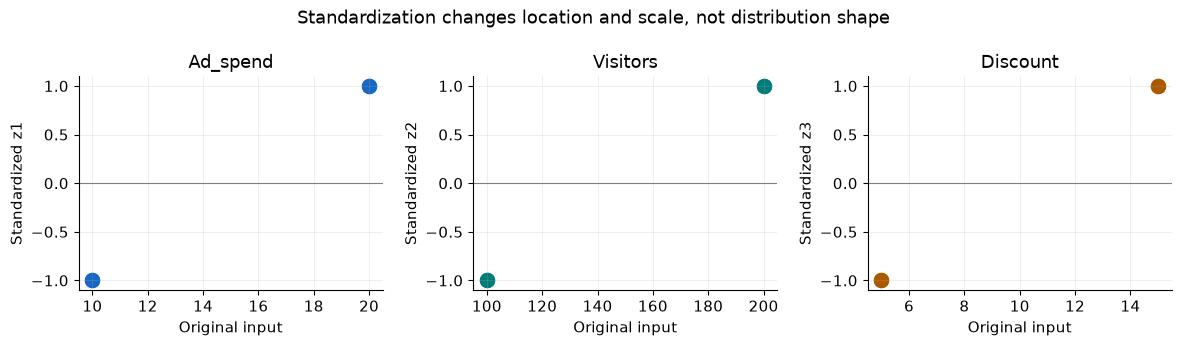

In [13]:
Z_train = (X_train - mu) / sigma
Z_test = (X_test - mu) / sigma
standardized_train = pd.DataFrame(Z_train, columns=["z1", "z2", "z3"], index=train.index)
standardized_train["Revenue_unchanged"] = y_train
standardized_test = pd.DataFrame(Z_test, columns=["z1", "z2", "z3"], index=test.index)
standardized_test["Revenue_unchanged"] = y_test
display(standardized_train)
print("Held-out inputs transformed with TRAINING statistics:")
display(standardized_test)
np.testing.assert_allclose(Z_train.mean(axis=0), 0, atol=1e-12)
np.testing.assert_allclose(Z_train.std(axis=0, ddof=0), 1)
np.testing.assert_allclose(Z_train[0], [-1, -1, -1])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for j, ax in enumerate(axes):
    ax.scatter(X_train[:, j], Z_train[:, j], s=100, color=COLORS[j], alpha=0.7)
    ax.set(title=FEATURES[j], xlabel="Original input", ylabel=f"Standardized z{j+1}")
    ax.axhline(0, color="gray", linewidth=0.8)
fig.suptitle("Standardization changes location and scale, not distribution shape")
fig.tight_layout()
plt.show()


## 15. Initialize Gradient Descent

Set $w_1=w_2=w_3=b=0$, $m=8$, and $\alpha=0.1$. The model is $\hat y=Zw+b$. This helper calculates predictions, errors, half-MSE, and gradients without modifying its inputs.


In [14]:
alpha = 0.1
w0 = np.zeros(len(FEATURES), dtype=float)
b0 = 0.0

def model_state(Z, y, w, b):
    predictions = Z @ w + b
    errors = predictions - y
    return {
        "predictions": predictions, "errors": errors,
        "cost": float(np.mean(errors ** 2) / 2),
        "grad_w": Z.T @ errors / len(y),
        "grad_b": float(errors.mean()),
    }

display(pd.Series([*w0, b0, alpha, m],
    index=["w1", "w2", "w3", "b", "alpha", "m"], name="Initial value").to_frame())


,Initial value
w1,0.000000
w2,0.000000
w3,0.000000
b,0.000000
alpha,0.100000
m,8.000000


## 16. Calculate Initial Predictions

$$
\hat y_{\mathrm{M01}}=0+0(-1)+0(-1)+0(-1)=0.
$$
Every initial prediction is zero.


In [15]:
initial = model_state(Z_train, y_train, w0, b0)
display(pd.DataFrame({"Actual": y_train, "Initial prediction": initial["predictions"]},
                     index=train.index))


,Actual,Initial prediction
ID,,
M01,67.000000,0.000000
M02,57.000000,0.000000
M03,93.000000,0.000000
M04,83.000000,0.000000
M05,83.000000,0.000000
M06,73.000000,0.000000
M07,117.000000,0.000000
M08,107.000000,0.000000


## 17. Calculate Prediction Errors

Training error is $e_i=\hat y_i-y_i$. For M01: $e=0-67=-67$.


In [16]:
initial_errors = pd.DataFrame({
    "Actual": y_train, "Predicted": initial["predictions"],
    "Error (predicted - actual)": initial["errors"],
}, index=train.index)
display(initial_errors)
print("Sum of initial errors:", initial["errors"].sum())


,Actual,Predicted,Error (predicted - actual)
ID,,,
M01,67.000000,0.000000,-67.000000
M02,57.000000,0.000000,-57.000000
M03,93.000000,0.000000,-93.000000
M04,83.000000,0.000000,-83.000000
M05,83.000000,0.000000,-83.000000
M06,73.000000,0.000000,-73.000000
M07,117.000000,0.000000,-117.000000
M08,107.000000,0.000000,-107.000000


Sum of initial errors: -680.0


## 18. Understand Why Errors Are Squared

Opposite errors can cancel: $(-10)+10=0$. Their squares do not: $(-10)^2+10^2=200$. Squaring prevents cancellation, penalizes larger misses, and gives a smooth objective. It also increases sensitivity to extreme residuals.


In [17]:
demo_errors = np.array([-10.0, 10.0])
display(pd.DataFrame({"Error": demo_errors, "Squared error": demo_errors ** 2}))
print("Signed sum:", demo_errors.sum(), "| Sum of squares:", (demo_errors ** 2).sum())


,Error,Squared error
0,-10.000000,100.000000
1,10.000000,100.000000


Signed sum: 0.0 | Sum of squares: 200.0


## 19. Calculate the Initial Cost

$$
J=\frac1{2m}\sum_i e_i^2,\qquad J_0=\frac{60632}{16}=3789.50.
$$
This is **half-MSE**, not MSE. The factor 1/2 simplifies derivatives. Cost is measured in squared revenue units.


In [18]:
initial_errors["Squared error"] = initial["errors"] ** 2
display(initial_errors)
sse0 = float((initial["errors"] ** 2).sum())
J0 = initial["cost"]
print(f"SSE = {sse0:.0f}; MSE = {sse0 / m:.2f}; half-MSE J0 = {J0:.2f}")
np.testing.assert_allclose(J0, 3789.5)


,Actual,Predicted,Error (predicted - actual),Squared error
ID,,,,
M01,67.000000,0.000000,-67.000000,"4,489.000000"
M02,57.000000,0.000000,-57.000000,"3,249.000000"
M03,93.000000,0.000000,-93.000000,"8,649.000000"
M04,83.000000,0.000000,-83.000000,"6,889.000000"
M05,83.000000,0.000000,-83.000000,"6,889.000000"
M06,73.000000,0.000000,-73.000000,"5,329.000000"
M07,117.000000,0.000000,-117.000000,"13,689.000000"
M08,107.000000,0.000000,-107.000000,"11,449.000000"


SSE = 60632; MSE = 7579.00; half-MSE J0 = 3789.50


## 20. Understand the Gradient

$$
g_j=\frac{\partial J}{\partial w_j}=\frac1m\sum_i e_i z_{ij},
\qquad
g_b=\frac{\partial J}{\partial b}=\frac1m\sum_i e_i.
$$
A positive derivative means increasing that parameter locally increases cost. Move in the opposite direction. Compute every gradient from the **same old parameters**.


## 21. Calculate Gradient for w₁

Multiply each error by its row's $z_1$, sum, and divide by 8:
$$
g_1=-80/8=-10.
$$


In [19]:
gradient_w1_table = pd.DataFrame({
    "Initial error": initial["errors"], "z1": Z_train[:, 0],
    "Error × z1": initial["errors"] * Z_train[:, 0],
}, index=train.index)
display(gradient_w1_table)
print(f"Sum = {gradient_w1_table['Error × z1'].sum():.0f}; g1 = {initial['grad_w'][0]:.2f}")


,Initial error,z1,Error × z1
ID,,,
M01,-67.000000,-1.000000,67.000000
M02,-57.000000,-1.000000,57.000000
M03,-93.000000,-1.000000,93.000000
M04,-83.000000,-1.000000,83.000000
M05,-83.000000,1.000000,-83.000000
M06,-73.000000,1.000000,-73.000000
M07,-117.000000,1.000000,-117.000000
M08,-107.000000,1.000000,-107.000000


Sum = -80; g1 = -10.00


## 22. Calculate Gradients for w₂, w₃, and b

$$
g_2=-120/8=-15,\quad g_3=40/8=5,\quad g_b=-680/8=-85.
$$


In [20]:
all_gradient_terms = pd.DataFrame({
    "e": initial["errors"],
    "z1": Z_train[:, 0], "z2": Z_train[:, 1], "z3": Z_train[:, 2],
    "e × z1": initial["errors"] * Z_train[:, 0],
    "e × z2": initial["errors"] * Z_train[:, 1],
    "e × z3": initial["errors"] * Z_train[:, 2],
}, index=train.index)
display(all_gradient_terms)
display(pd.DataFrame({
    "Sum": [*(Z_train.T @ initial["errors"]), initial["errors"].sum()],
    "Gradient (sum / 8)": [*initial["grad_w"], initial["grad_b"]],
}, index=["w1", "w2", "w3", "b"]))
np.testing.assert_allclose(initial["grad_w"], [-10, -15, 5])
np.testing.assert_allclose(initial["grad_b"], -85)


,e,z1,z2,z3,e × z1,e × z2,e × z3
ID,,,,,,,
M01,-67.000000,-1.000000,-1.000000,-1.000000,67.000000,67.000000,67.000000
M02,-57.000000,-1.000000,-1.000000,1.000000,57.000000,57.000000,-57.000000
M03,-93.000000,-1.000000,1.000000,-1.000000,93.000000,-93.000000,93.000000
M04,-83.000000,-1.000000,1.000000,1.000000,83.000000,-83.000000,-83.000000
M05,-83.000000,1.000000,-1.000000,-1.000000,-83.000000,83.000000,83.000000
M06,-73.000000,1.000000,-1.000000,1.000000,-73.000000,73.000000,-73.000000
M07,-117.000000,1.000000,1.000000,-1.000000,-117.000000,-117.000000,117.000000
M08,-107.000000,1.000000,1.000000,1.000000,-107.000000,-107.000000,-107.000000


,Sum,Gradient (sum / 8)
w1,-80.000000,-10.000000
w2,-120.000000,-15.000000
w3,40.000000,5.000000
b,-680.000000,-85.000000


## 23. Understand the Learning Rate

$$
\theta_{\mathrm{new}}=\theta_{\mathrm{old}}-\alpha g,\qquad\alpha=0.1.
$$
Too small can be slow; too large can overshoot or diverge. Here the standardized columns and constant bias column are orthogonal and the half-MSE Hessian is the identity. Thus $0<\alpha<2$ converges **for this dataset**; this range is not universal.


In [21]:
design_with_bias = np.column_stack([np.ones(m), Z_train])
hessian = design_with_bias.T @ design_with_bias / m
largest_eigenvalue = np.linalg.eigvalsh(hessian).max()
display(pd.DataFrame(hessian, index=["b", "w1", "w2", "w3"], columns=["b", "w1", "w2", "w3"]))
print(f"For this quadratic: 0 < alpha < {2 / largest_eigenvalue:.2f}; chosen alpha = {alpha}")


,b,w1,w2,w3
b,1.000000,0.000000,0.000000,0.000000
w1,0.000000,1.000000,0.000000,0.000000
w2,0.000000,0.000000,1.000000,0.000000
w3,0.000000,0.000000,0.000000,1.000000


For this quadratic: 0 < alpha < 2.00; chosen alpha = 0.1


## 24. Update w₁

$$
w_1^{(1)}=0-0.1(-10)=1.
$$
The next four cells use saved initial gradients, so their updates are simultaneous mathematically.


In [22]:
w1_after_first = w0[0] - alpha * initial["grad_w"][0]
print(f"w1 after iteration 1 = {w1_after_first:.2f}")


w1 after iteration 1 = 1.00


## 25. Update w₂

$$
w_2^{(1)}=0-0.1(-15)=1.5.
$$


In [23]:
w2_after_first = w0[1] - alpha * initial["grad_w"][1]
print(f"w2 after iteration 1 = {w2_after_first:.2f}")


w2 after iteration 1 = 1.50


## 26. Update w₃

$$
w_3^{(1)}=0-0.1(5)=-0.5.
$$


In [24]:
w3_after_first = w0[2] - alpha * initial["grad_w"][2]
print(f"w3 after iteration 1 = {w3_after_first:.2f}")


w3 after iteration 1 = -0.50


## 27. Update Bias b

$$
b^{(1)}=0-0.1(-85)=8.5.
$$


In [25]:
b_after_first = b0 - alpha * initial["grad_b"]
w_after_first = np.array([w1_after_first, w2_after_first, w3_after_first])
display(pd.Series([*w_after_first, b_after_first],
    index=["w1", "w2", "w3", "b"], name="After iteration 1").to_frame())


,After iteration 1
w1,1.000000
w2,1.500000
w3,-0.500000
b,8.500000


## 28. Form the Equation After Iteration 1

$$
\hat y=8.5+1z_1+1.5z_2-0.5z_3.
$$
For M01 all three z values are **−1**:
$$
\hat y=8.5-1-1.5+0.5=6.5.
$$


In [26]:
first = model_state(Z_train, y_train, w_after_first, b_after_first)
print(f"M01 prediction = {first['predictions'][0]:.2f}")
np.testing.assert_allclose(first["predictions"][0], 6.5)


M01 prediction = 6.50


## 29. Recalculate the Cost After Iteration 1

Recompute all eight predictions and residuals:
$$
J_1=3069.875<3789.50=J_0.
$$


In [27]:
first_iteration_table = pd.DataFrame({
    "Actual": y_train, "Predicted": first["predictions"],
    "Error": first["errors"], "Squared error": first["errors"] ** 2,
}, index=train.index)
display(first_iteration_table)
J1 = first["cost"]
print(f"J1 = {J1:.6f}")
print(f"Cost reduction = {J0 - J1:.6f} ({100 * (J0 - J1) / J0:.4f}%)")
np.testing.assert_allclose(J1, 3069.875)


,Actual,Predicted,Error,Squared error
ID,,,,
M01,67.000000,6.500000,-60.500000,"3,660.250000"
M02,57.000000,5.500000,-51.500000,"2,652.250000"
M03,93.000000,9.500000,-83.500000,"6,972.250000"
M04,83.000000,8.500000,-74.500000,"5,550.250000"
M05,83.000000,8.500000,-74.500000,"5,550.250000"
M06,73.000000,7.500000,-65.500000,"4,290.250000"
M07,117.000000,11.500000,-105.500000,"11,130.250000"
M08,107.000000,10.500000,-96.500000,"9,312.250000"


J1 = 3069.875000
Cost reduction = 719.625000 (18.9900%)


## 30. Perform Gradient Descent Iteration 2

Use the errors after iteration 1:
$$
(g_1,g_2,g_3,g_b)=(-9,-13.5,4.5,-76.5).
$$


In [28]:
second_gradient_terms = pd.DataFrame({
    "Error after iteration 1": first["errors"],
    "e × z1": first["errors"] * Z_train[:, 0],
    "e × z2": first["errors"] * Z_train[:, 1],
    "e × z3": first["errors"] * Z_train[:, 2],
}, index=train.index)
display(second_gradient_terms)
display(pd.Series([*first["grad_w"], first["grad_b"]],
    index=["g1", "g2", "g3", "gb"], name="Iteration 2 gradients").to_frame())


,Error after iteration 1,e × z1,e × z2,e × z3
ID,,,,
M01,-60.500000,60.500000,60.500000,60.500000
M02,-51.500000,51.500000,51.500000,-51.500000
M03,-83.500000,83.500000,-83.500000,83.500000
M04,-74.500000,74.500000,-74.500000,-74.500000
M05,-74.500000,-74.500000,74.500000,74.500000
M06,-65.500000,-65.500000,65.500000,-65.500000
M07,-105.500000,-105.500000,-105.500000,105.500000
M08,-96.500000,-96.500000,-96.500000,-96.500000


,Iteration 2 gradients
g1,-9.000000
g2,-13.500000
g3,4.500000
gb,-76.500000


## 31. Update All Weights in Iteration 2

$$
\begin{aligned}
w_1&=1-0.1(-9)=1.90,\\
w_2&=1.5-0.1(-13.5)=2.85,\\
w_3&=-0.5-0.1(4.5)=-0.95,\\
b&=8.5-0.1(-76.5)=16.15.
\end{aligned}
$$


In [29]:
w_after_second = w_after_first - alpha * first["grad_w"]
b_after_second = b_after_first - alpha * first["grad_b"]
second = model_state(Z_train, y_train, w_after_second, b_after_second)
display(pd.Series([*w_after_second, b_after_second, second["cost"]],
    index=["w1", "w2", "w3", "b", "J"], name="After iteration 2").to_frame())
np.testing.assert_allclose(w_after_second, [1.9, 2.85, -0.95])
np.testing.assert_allclose(b_after_second, 16.15)
np.testing.assert_allclose(second["cost"], 2486.97875)


,After iteration 2
w1,1.900000
w2,2.850000
w3,-0.950000
b,16.150000
J,"2,486.978750"


## 32. Continue Gradient Descent Iterations

The full-batch loop implements the same arithmetic. Iteration 0 is before any update; iteration 200 is after 200 updates. Each stored cost corresponds to that row's parameters. This fixed run reproduces the posters; no library estimator performs the training.


,w1,w2,w3,b,cost,max_abs_gradient
iteration,,,,,,
0,0.000000,0.000000,0.000000,0.000000,"3,789.500000",85.000000
1,1.000000,1.500000,-0.500000,8.500000,"3,069.875000",76.500000
2,1.900000,2.850000,-0.950000,16.150000,"2,486.978750",68.850000
10,6.513216,9.769823,-3.256608,55.362333,462.471579,29.637667
20,8.784233,13.176350,-4.392117,74.665984,57.982594,10.334016
50,9.948462,14.922693,-4.974231,84.561929,2.100601,0.438071
100,9.999734,14.999602,-4.999867,84.997742,2.000003,0.002258
200,10.000000,15.000000,-5.000000,85.000000,2.000000,0.000000


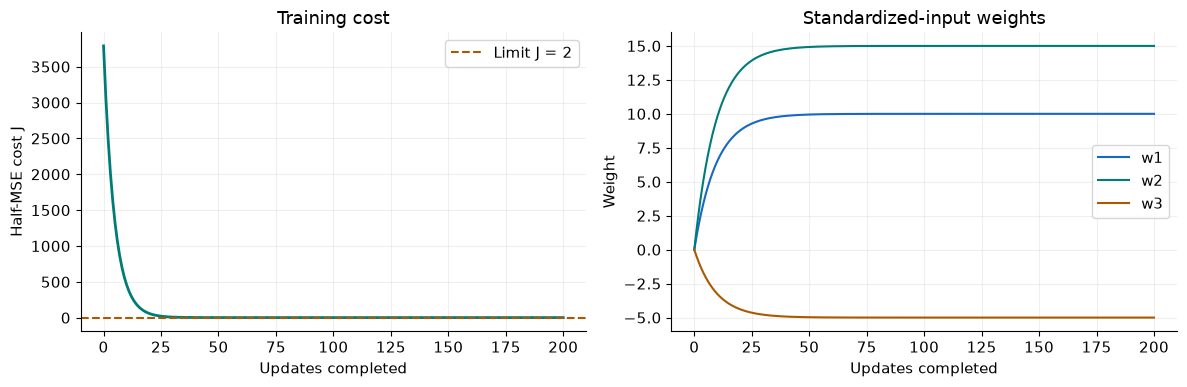

In [30]:
def fit_gradient_descent(Z, y, learning_rate=0.1, n_updates=200):
    weights = np.zeros(Z.shape[1], dtype=float)
    bias = 0.0
    records = []
    for iteration in range(n_updates + 1):
        current = model_state(Z, y, weights, bias)
        records.append({
            "iteration": iteration,
            "w1": weights[0], "w2": weights[1], "w3": weights[2],
            "b": bias, "cost": current["cost"],
            "g1": current["grad_w"][0], "g2": current["grad_w"][1],
            "g3": current["grad_w"][2], "gb": current["grad_b"],
            "max_abs_gradient": max(np.max(np.abs(current["grad_w"])), abs(current["grad_b"])),
        })
        if iteration == n_updates:
            break
        # Both updates use gradients computed BEFORE either parameter changes.
        new_weights = weights - learning_rate * current["grad_w"]
        new_bias = bias - learning_rate * current["grad_b"]
        weights, bias = new_weights, new_bias
    return weights, bias, pd.DataFrame(records).set_index("iteration")

w_final, b_final, history = fit_gradient_descent(Z_train, y_train, alpha, 200)
display(history.loc[[0, 1, 2, 10, 20, 50, 100, 200],
                    ["w1", "w2", "w3", "b", "cost", "max_abs_gradient"]])
np.testing.assert_allclose(history.loc[1, ["w1", "w2", "w3"]].to_numpy(dtype=float), w_after_first)
np.testing.assert_allclose(history.loc[2, ["w1", "w2", "w3"]].to_numpy(dtype=float), w_after_second)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.index, history["cost"], color=COLORS[1], linewidth=2)
axes[0].set(xlabel="Updates completed", ylabel="Half-MSE cost J", title="Training cost")
axes[0].axhline(2, color=COLORS[2], linestyle="--", label="Limit J = 2")
axes[0].legend()
for name, color in zip(["w1", "w2", "w3"], COLORS):
    axes[1].plot(history.index, history[name], label=name, color=color)
axes[1].set(xlabel="Updates completed", ylabel="Weight", title="Standardized-input weights")
axes[1].legend()
fig.tight_layout()
plt.show()


## 33. Understand Convergence

After 200 updates the largest absolute gradient is below $10^{-7}$, and cost is stable near 2. A practical stopping rule uses a gradient/cost tolerance and an iteration cap.

The synthetic target contains an interaction $2z_1z_2$ that the additive MLR model cannot fit, leaving residuals ±2. The optimal half-MSE is therefore $2^2/2=2$, not zero.

These verification formulas hold **only for this balanced, orthogonal dataset**:
$$
\theta_t=(1-0.9^t)\theta_*,
\quad \theta_*=(85,10,15,-5)\text{ in order }(b,w_1,w_2,w_3),
\quad J_t=2+3787.5(0.81)^t.
$$


In [31]:
gradient_tolerance = 1e-7
cost_change_tolerance = 1e-10
cost_changes = history["cost"].diff().abs()
converged_rows = history.index[
    (history["max_abs_gradient"] < gradient_tolerance) &
    (cost_changes < cost_change_tolerance)
]
print("First stored iteration meeting both tolerances:", int(converged_rows[0]))
print(f"Final maximum absolute gradient: {history.iloc[-1]['max_abs_gradient']:.3e}")
print(f"Final cost: {history.iloc[-1]['cost']:.12f}")
t_values = history.index.to_numpy()
expected_costs = 2 + 3787.5 * (0.81 ** t_values)
np.testing.assert_allclose(history["cost"], expected_costs, rtol=1e-10, atol=1e-10)
assert history["cost"].diff().dropna().max() < 1e-10
assert history.iloc[-1]["max_abs_gradient"] < gradient_tolerance

# Independent least-squares reference checks our gradient-descent implementation.
theta_lstsq, _, rank, _ = np.linalg.lstsq(design_with_bias, y_train, rcond=None)
theta_gd = np.r_[b_final, w_final]
assert rank == 4
np.testing.assert_allclose(theta_gd, theta_lstsq, atol=1e-6, rtol=0)
display(pd.DataFrame({"Gradient descent": theta_gd, "Least-squares reference": theta_lstsq},
                     index=["b", "w1", "w2", "w3"]))
np.testing.assert_allclose(
    y_train - design_with_bias @ theta_lstsq,
    2 * Z_train[:, 0] * Z_train[:, 1], atol=1e-10
)
print("All convergence and independent least-squares checks passed.")


First stored iteration meeting both tolerances: 196
Final maximum absolute gradient: 5.997e-08
Final cost: 2.000000000000


,Gradient descent,Least-squares reference
b,85.000000,85.000000
w1,10.000000,10.000000
w2,15.000000,15.000000
w3,-5.000000,-5.000000


All convergence and independent least-squares checks passed.


## 34. Write the Final Standardized MLR Model

$$
\boxed{\hat y\approx85+10z_1+15z_2-5z_3}.
$$
Only inputs are standardized. Revenue remains in ₹ thousands/day. A one-SD increase in visitors corresponds to ₹15 thousand/day more predicted revenue, other inputs fixed. Displayed integers are rounded; subsequent calculations retain the actual parameters.


In [32]:
print(f"ŷ = {b_final:.8f} + {w_final[0]:.8f}z1 + {w_final[1]:.8f}z2 {w_final[2]:+.8f}z3")
np.testing.assert_allclose(w_final, [10, 15, -5], atol=1e-6, rtol=0)
np.testing.assert_allclose(b_final, 85, atol=1e-6, rtol=0)


ŷ = 84.99999994 + 9.99999999z1 + 14.99999999z2 -5.00000000z3


## 35. Convert w₁ Back to Original Units

$$
\beta_1=w_1/\sigma_1=10/5=2.
$$
₹1 thousand/day more ad spend corresponds to ₹2 thousand/day more predicted revenue, holding the other inputs fixed.


In [33]:
beta_ad = w_final[0] / sigma[0]
print(f"Ad-spend coefficient = {beta_ad:.8f}")


Ad-spend coefficient = 2.00000000


## 36. Convert w₂ Back to Original Units

$$
\beta_2=w_2/\sigma_2=15/50=0.30.
$$
One additional visitor/day corresponds to ₹0.30 thousand/day = ₹300/day more predicted revenue.


In [34]:
beta_visitors = w_final[1] / sigma[1]
print(f"Visitor coefficient = {beta_visitors:.8f} INR thousands per visitor")
print(f"Equivalent rupees per visitor = {beta_visitors * 1000:.2f}")


Visitor coefficient = 0.30000000 INR thousands per visitor
Equivalent rupees per visitor = 300.00


## 37. Convert w₃ Back to Original Units

$$
\beta_3=w_3/\sigma_3=-5/5=-1.
$$
One more discount percentage point corresponds to ₹1 thousand/day less predicted revenue, holding other inputs fixed.


In [35]:
beta_discount = w_final[2] / sigma[2]
print(f"Discount coefficient = {beta_discount:.8f}")


Discount coefficient = -1.00000000


## 38. Calculate the Original-Scale Intercept

Substitute $z_j=(X_j-\mu_j)/\sigma_j$ and collect constants:
$$
\beta_0=b-\sum_j\beta_j\mu_j
=85-2(15)-0.30(150)-(-1)(10)=20.
$$
No target SD or target mean is needed because Y was not standardized.


In [36]:
beta = w_final / sigma
intercept = b_final - mu @ beta
display(pd.DataFrame({
    "Mean": mu, "Original coefficient": beta, "Coefficient × mean": beta * mu,
}, index=FEATURES))
print(f"Original-scale intercept = {intercept:.8f}")


,Mean,Original coefficient,Coefficient × mean
Ad_spend,15.000000,2.000000,30.000000
Visitors,150.000000,0.300000,45.000000
Discount,10.000000,-1.000000,-10.000000


Original-scale intercept = 19.99999999


## 39. Write the Final MLR Equation

$$
\boxed{\text{Revenue}\approx20+2(\text{Ad spend})+
0.30(\text{Visitors})-1(\text{Discount})}.
$$
Money is in ₹ thousands/day. Visitors are people/day. Enter discount as **8 for 8%**, not 0.08.


In [37]:
original_coefficients = pd.Series([intercept, *beta],
    index=["Intercept", *FEATURES], name="Original-scale coefficient")
display(original_coefficients.to_frame())
np.testing.assert_allclose([intercept, *beta], [20, 2, 0.3, -1], atol=1e-6, rtol=0)
np.testing.assert_allclose(X_train @ beta + intercept, Z_train @ w_final + b_final, atol=1e-10, rtol=0)
np.testing.assert_allclose(X_test @ beta + intercept, Z_test @ w_final + b_final, atol=1e-10, rtol=0)
print("Original-input and standardized-input equations give identical predictions.")


,Original-scale coefficient
Intercept,20.000000
Ad_spend,2.000000
Visitors,0.300000
Discount,-1.000000


Original-input and standardized-input equations give identical predictions.


## 40. Make a Prediction Manually

Held-out M09: ad spend 12, visitors 140, discount 8:
$$
\hat y=20+2(12)+0.30(140)-8=78.
$$
Predicted daily revenue: **₹78,000**. Compare rounded poster arithmetic with the fitted parameters.


In [38]:
manual_row = test.loc["M09", FEATURES].to_numpy(dtype=float)
manual_terms = pd.Series([20.0, 2.0 * manual_row[0], 0.30 * manual_row[1], -manual_row[2]],
    index=["Intercept", "Ad-spend contribution", "Visitor contribution", "Discount contribution"])
poster_prediction = manual_terms.sum()
fitted_prediction = intercept + manual_row @ beta
display(manual_terms.rename("Contribution (INR thousands/day)").to_frame())
print(f"Manual prediction with rounded coefficients: {poster_prediction:.2f}")
print(f"Prediction with 200-update parameters: {fitted_prediction:.10f}")
print(f"Predicted daily revenue: INR {fitted_prediction * 1000:,.2f}")
np.testing.assert_allclose(fitted_prediction, 78, atol=1e-6, rtol=0)


,Contribution (INR thousands/day)
Intercept,20.000000
Ad-spend contribution,24.000000
Visitor contribution,42.000000
Discount contribution,-8.000000


Manual prediction with rounded coefficients: 78.00
Prediction with 200-update parameters: 77.9999999450
Predicted daily revenue: INR 78,000.00


## 41. Calculate the Residual

For reporting, use actual − predicted, opposite to the training-error convention:
$$
r_{\mathrm{M09}}=79-78=+1.
$$
This means underprediction by ₹1,000. Squaring gives the same result under either sign convention.


In [39]:
manual_actual = test.loc["M09", TARGET]
manual_residual = manual_actual - fitted_prediction
print(f"Actual = {manual_actual:.2f}; predicted = {fitted_prediction:.2f}; "
      f"residual = {manual_residual:+.2f} INR thousands/day")
np.testing.assert_allclose(manual_residual, 1, atol=1e-6, rtol=0)


Actual = 79.00; predicted = 78.00; residual = +1.00 INR thousands/day


## 42. Evaluate the Model

$$
\mathrm{MAE}=\frac1n\sum_i|y_i-\hat y_i|,\quad
\mathrm{RMSE}=\sqrt{\frac1n\sum_i(y_i-\hat y_i)^2},\quad
R^2=1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}.
$$
Use **each split's own mean** in its $R^2$ denominator. MAE/RMSE are in revenue units, while $R^2$ is dimensionless.

Expected: training MAE 2, RMSE 2, $R^2\approx0.9887$; held-out MAE 1, RMSE 1, $R^2\approx0.9877$.

**Two synthetic test rows illustrate arithmetic, not generalization.** A better held-out score here is not evidence of real-world reliability. A deployment would require representative evaluation, more data, and appropriate regression diagnostics.


,MAE,RMSE,R2,SSE,SST
Training (8 rows),2.000000,2.000000,0.988701,32.000000,"2,832.000000"
Held out (2 rows),1.000000,1.000000,0.987654,2.000000,162.000000


Training predictions:


,Ad_spend,Visitors,Discount,Revenue,Prediction,Residual_actual_minus_predicted
ID,,,,,,
M01,10.000000,100,5,67,65.000000,2.000000
M02,10.000000,100,15,57,55.000000,2.000000
M03,10.000000,200,5,93,95.000000,-2.000000
M04,10.000000,200,15,83,85.000000,-2.000000
M05,20.000000,100,5,83,85.000000,-2.000000
M06,20.000000,100,15,73,75.000000,-2.000000
M07,20.000000,200,5,117,115.000000,2.000000
M08,20.000000,200,15,107,105.000000,2.000000


Held-out predictions:


,Ad_spend,Visitors,Discount,Revenue,Prediction,Residual_actual_minus_predicted
ID,,,,,,
M09,12.000000,140,8,79,78.000000,1.000000
M10,18.000000,180,12,97,98.000000,-1.000000


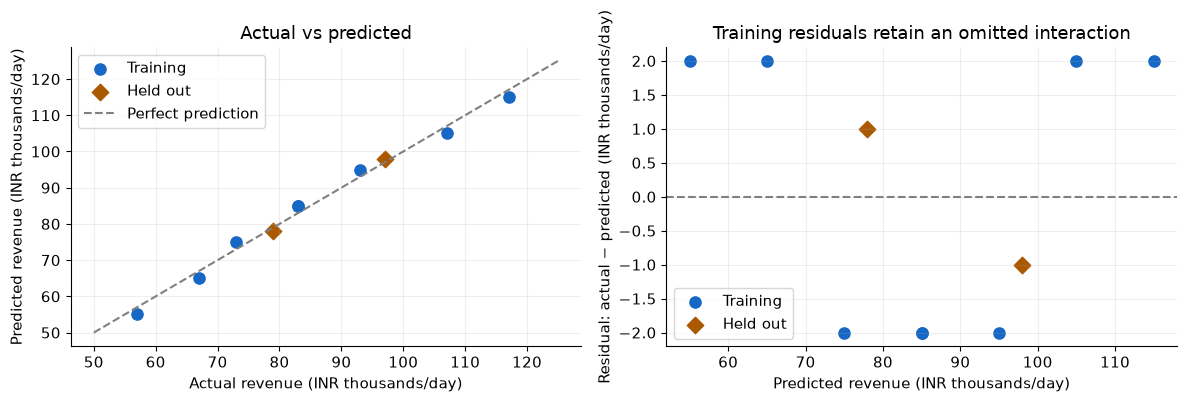

In [40]:
def regression_metrics(actual, predicted):
    residual = actual - predicted
    sse = float(residual @ residual)
    sst = float(np.sum((actual - actual.mean()) ** 2))
    return {
        "MAE": float(np.mean(np.abs(residual))),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": 1 - sse / sst if sst > 0 else np.nan,
        "SSE": sse, "SST": sst,
    }

train_predictions = X_train @ beta + intercept
test_predictions = X_test @ beta + intercept
train_results = train.copy()
train_results["Prediction"] = train_predictions
train_results["Residual_actual_minus_predicted"] = y_train - train_predictions
test_results = test.copy()
test_results["Prediction"] = test_predictions
test_results["Residual_actual_minus_predicted"] = y_test - test_predictions
metrics = pd.DataFrame({
    "Training (8 rows)": regression_metrics(y_train, train_predictions),
    "Held out (2 rows)": regression_metrics(y_test, test_predictions),
}).T
display(metrics)
print("Training predictions:")
display(train_results)
print("Held-out predictions:")
display(test_results)
np.testing.assert_allclose(metrics["MAE"], [2, 1], atol=1e-6, rtol=0)
np.testing.assert_allclose(metrics["RMSE"], [2, 1], atol=1e-6, rtol=0)
np.testing.assert_allclose(test_predictions, [78, 98], atol=1e-6, rtol=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_train, train_predictions, color=COLORS[0], label="Training", s=65)
axes[0].scatter(y_test, test_predictions, color=COLORS[2], marker="D", label="Held out", s=70)
axes[0].plot([50, 125], [50, 125], color="gray", linestyle="--", label="Perfect prediction")
axes[0].set(xlabel="Actual revenue (INR thousands/day)",
    ylabel="Predicted revenue (INR thousands/day)", title="Actual vs predicted")
axes[0].legend()
axes[1].scatter(train_predictions, y_train - train_predictions, color=COLORS[0], label="Training", s=65)
axes[1].scatter(test_predictions, y_test - test_predictions, color=COLORS[2], marker="D", label="Held out", s=70)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set(xlabel="Predicted revenue (INR thousands/day)",
    ylabel="Residual: actual − predicted (INR thousands/day)", title="Training residuals retain an omitted interaction")
axes[1].legend()
fig.tight_layout()
plt.show()


## 43. Interpret the Final Coefficients

Hold the other predictors fixed for each interpretation.

| Term | Coefficient | Interpretation |
|---|---:|---|
| Ad spend | 2 | +₹1 thousand/day ad spend corresponds to +₹2 thousand/day predicted revenue |
| Visitors | 0.30 | +1 visitor/day corresponds to +₹300/day predicted revenue |
| Discount | −1 | +1 discount percentage point corresponds to −₹1 thousand/day predicted revenue |
| Intercept | 20 | Prediction at zero inputs, outside the observed training range |

These are associations, not causal effects. Comparing raw coefficient magnitudes does not rank importance because the inputs have different units. Standardized coefficients describe changes per training SD but also do not establish causality.


## 44. Summarize the Complete MLR + Gradient Descent Flow

**Business question → inspect and validate → clean → split → fit training scaler → initialize → predict → half-MSE cost → gradients → simultaneous update → repeat → convergence → original units → evaluate → interpret.**

| Checkpoint | Result |
|---|---|
| Raw / cleaned rows | 14 / 10 |
| Training / held-out | 8 / 2 |
| Training means | (15, 150, 10) |
| Training population SDs | (5, 50, 5) |
| Initial cost | 3789.50 |
| Cost after update 1 | 3069.875 |
| Cost after update 2 | 2486.97875 |
| Cost after 200 updates | ≈ 2.00 |
| Standardized-input model | $\hat y\approx85+10z_1+15z_2-5z_3$ |
| Original-input model | $\hat y\approx20+2X_1+0.30X_2-X_3$ |
| M09 predicted revenue | ₹78,000/day |

The final cell verifies key results and exports reproducible CSVs. Computations retain full precision; rounding is only for presentation.


In [41]:
np.testing.assert_allclose(history.loc[[0, 1, 2], "cost"],
    [3789.5, 3069.875, 2486.97875], atol=1e-9, rtol=0)
np.testing.assert_allclose(history.iloc[-1]["cost"], 2, atol=1e-9, rtol=0)
np.testing.assert_allclose(metrics.loc["Training (8 rows)", "R2"], 1 - 32 / 2832, atol=1e-9, rtol=0)
np.testing.assert_allclose(metrics.loc["Held out (2 rows)", "R2"], 1 - 2 / 162, atol=1e-8, rtol=0)

output_dir = Path("mlr_notebook_outputs")
output_dir.mkdir(exist_ok=True)
raw.to_csv(output_dir / "01_raw_marketing_data.csv", index=False)
cleaning_log.to_csv(output_dir / "02_cleaning_log.csv", index=False)
cleaned.to_csv(output_dir / "03_cleaned_data.csv", index=False)
train.to_csv(output_dir / "04_training_data.csv")
test.to_csv(output_dir / "05_held_out_data.csv")
scaling_statistics.to_csv(output_dir / "06_training_scaler.csv", index_label="Feature")
standardized_train.to_csv(output_dir / "07_standardized_training_data.csv")
history.to_csv(output_dir / "08_gradient_descent_history.csv")
original_coefficients.to_csv(output_dir / "09_original_scale_coefficients.csv", index_label="Term")
train_results.to_csv(output_dir / "10_training_predictions.csv")
test_results.to_csv(output_dir / "11_held_out_predictions.csv")
metrics.to_csv(output_dir / "12_evaluation_metrics.csv", index_label="Split")
print("All numerical checks passed.")
print(f"Saved 12 CSV files in: {output_dir.resolve()}")


All numerical checks passed.
Saved 12 CSV files in: C:\manish\ejagruti\genai\myprojects\aiml\MLR\mlr_notebook_outputs
